In [1]:

import argparse
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import wandb

%matplotlib inline

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
ENTITY  = "behzadshomali"
PROJECT = "loop_MTP_paper"


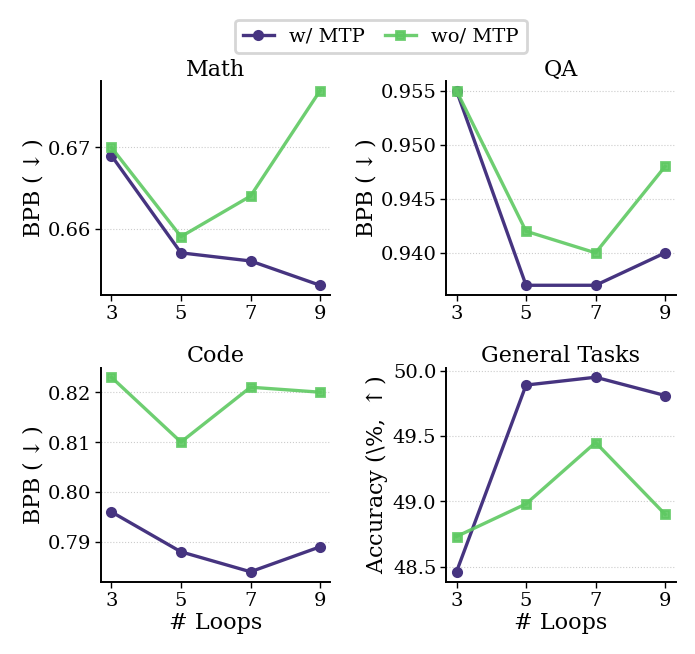

In [2]:
# ── ACL/EMNLP single-column style ───────────────────────────────────────────
plt.rcParams.update({
    "font.family":           "serif",
    "font.serif":            ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset":      "dejavuserif",
    "font.size":             8,
    "axes.titlesize":        8,
    "axes.labelsize":        8,
    "legend.fontsize":       7,
    "legend.title_fontsize": 7,
    "xtick.labelsize":       7,
    "ytick.labelsize":       7,
    "axes.linewidth":        0.7,
    "xtick.major.width":     0.5,
    "ytick.major.width":     0.5,
    "lines.linewidth":       1.2,
    "figure.dpi":            200,
    "savefig.dpi":           300,
    "savefig.bbox":          "tight",
})

loops = [3, 5, 7, 9, 11, ]

# ── BPB data (math / qa / code) ──────────────────────────────────────────────
looped_bpb = {
    "math": [0.670, 0.659, 0.664, 0.677, 0.670],
    "qa":   [0.955, 0.942, 0.940, 0.948, 0.946],
    "code": [0.823, 0.810, 0.821, 0.820, 0.818],
}
mtplooped_bpb = {
    # "math": [0.675, 0.665, 0.663, 0.666, 0.669],
    # "qa":   [0.962, 0.945, 0.938, 0.938, 0.951],
    # "code": [0.819, 0.816, 0.805, 0.823, 0.803],
    "math": [0.669, 0.657, 0.656, 0.653, 0.67],
    "qa":   [0.955, 0.937, 0.937, 0.94, 0.943],
    "code": [0.796, 0.788, 0.784, 0.789, 0.803]

}
nonlooped_bpb = {
    "math": [0.714, None, None, None, None],
    "qa":   [1.001, None, None, None, None],
    "code": [0.868, None, None, None, None],
}

# ── Accuracy data (GSM8K) ────────────────────────────────────────────────────
looped_acc = {
    "accuracy": [48.73, 48.98, 49.45, 48.90, 48.88],
}
mtplooped_acc = {
    "accuracy": [48.46, 49.89, 49.95, 49.81, 49.74],
}
nonlooped_acc = {
    "accuracy": [45.95, None, None, None, None],
}

indices_to_show = [0, 1, 2, 3]

# Each panel: (data-key, looped, mtplooped, nonlooped, title, ylabel)
PANELS = [
    ("math",     looped_bpb, mtplooped_bpb, nonlooped_bpb, "Math", "BPB ($\\downarrow$)"),
    ("qa",       looped_bpb, mtplooped_bpb, nonlooped_bpb, "QA",   "BPB ($\\downarrow$)"),
    ("code",     looped_bpb, mtplooped_bpb, nonlooped_bpb, "Code", "BPB ($\\downarrow$)"),
    ("accuracy", looped_acc, mtplooped_acc, nonlooped_acc, "General Tasks", "Accuracy (\\%, $\\uparrow$)"),
]

PALETTE    = [plt.cm.viridis(v) for v in np.linspace(0.15, 0.75, 2)]
# LINESTYLES = ["-", "--"]
LINESTYLES = ["-", "-"]
ALPHAS = [1.0, 0.9]
MARKERS    = ["o", "s"]
NONLOOPED_COLOR = "#444444"

# 2x2 grid sized to fit a single text column (~3.3in wide).
fig, axes = plt.subplots(2, 2, figsize=(3.3, 2.9))
axes = axes.flatten()

cnt = 0
for ax, (key, looped, mtplooped, nonlooped, title, ylabel) in zip(axes, PANELS):
    baselines = [("w/ MTP", mtplooped), ("wo/ MTP", looped)]
    for j, (name, data) in enumerate(baselines):
        ys = np.array([np.nan if v is None else v for v in data[key]], dtype=float)[indices_to_show]
        xs = np.array(loops, dtype=float)[indices_to_show]
        mask = ~np.isnan(ys)
        ax.plot(
            xs[mask], ys[mask],
            label=name,
            color=PALETTE[(j+0)%2],
            linestyle=LINESTYLES[(j+0)%2],
            marker=MARKERS[(j+0)%2],
            markersize=3,
            linewidth=1.2,
            alpha=ALPHAS[j],
        )

    ## Non-looped baseline as a horizontal reference line
    # nl_vals = [v for v in nonlooped[key] if v is not None]
    # if nl_vals:
    #     ax.axhline(
    #         nl_vals[0],
    #         color=NONLOOPED_COLOR,
    #         linestyle=":",
    #         linewidth=1.4,
    #         label="Non-looped",
    #     )

    ax.set_title(title, pad=2)
    if cnt > 1:
        ax.set_xlabel("# Loops", labelpad=1)
    ax.set_ylabel(ylabel, labelpad=1)
    ax.set_xticks(np.asanyarray(loops)[indices_to_show])
    
    ax.tick_params(length=2, pad=1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.4, alpha=0.6, color="#aaaaaa")
    ax.set_axisbelow(True)
    cnt += 1

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.55, 1.08),
    ncol=len(handles),
    columnspacing=1.0,
    handlelength=1.6,
    frameon=True,
    framealpha=0.8,
    edgecolor="#cccccc",
)

fig.tight_layout(pad=0.1, w_pad=1, h_pad=1)
Path("./plots").mkdir(exist_ok=True)
fig.savefig("./plots/loopMTP_vs_loop_bpb_acc.pdf", bbox_inches="tight")
plt.show()


# MATH: ACC and extrapolation

MTP (MTPLayers=12): accuracy = 0.674 * loops + 11.210
  Loops=9: predicted = 17.273
  Loops=11: predicted = 18.620
  Loops=13: predicted = 19.967
  Loops=15: predicted = 21.315
  Loops=20: predicted = 24.683

Non-MTP: accuracy = 0.615 * loops + 11.307
  Loops=9: predicted = 16.844
  Loops=11: predicted = 18.074
  Loops=13: predicted = 19.305
  Loops=15: predicted = 20.535
  Loops=20: predicted = 23.611



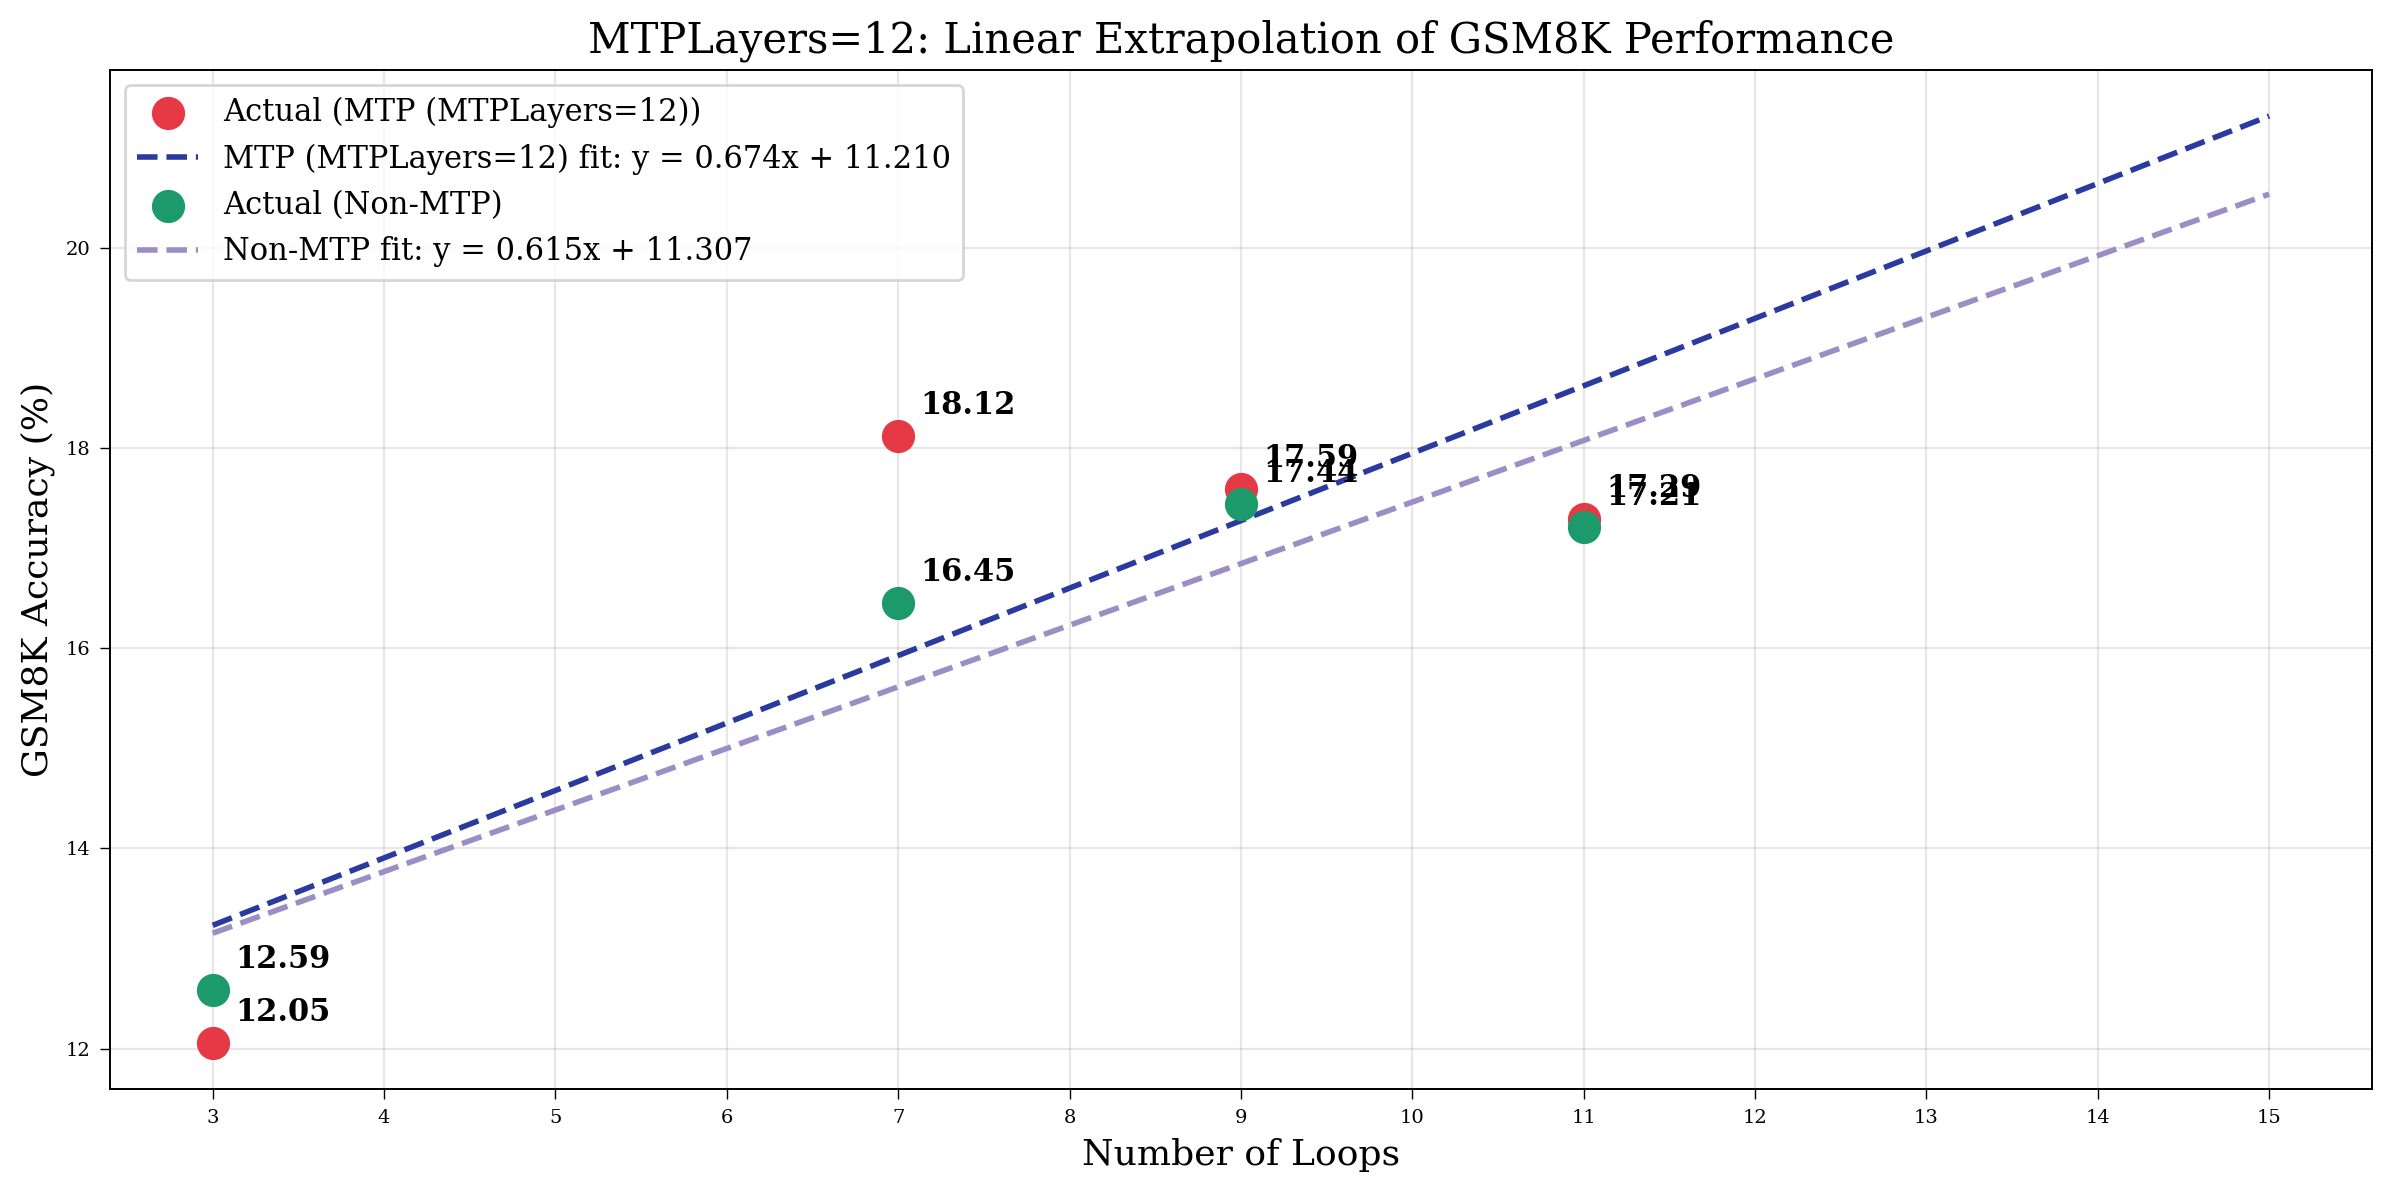

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# MTPLayers=12 data points: Loops -> accuracy (%)
loops_data = np.array([3, 5, 7, 9, 11])
# mtp_acc_data =     np.array([5.458, 12.055, 14.329,   18.120, 17.589, 17.286])
mtp_acc_data =     np.array([12.055, None,   18.120, 17.589, 17.286])
non_mtp_acc_data = np.array([12.585, None,   16.452, 17.437, 17.21])

series = [
    ("MTP (MTPLayers=12)", mtp_acc_data,     "#e63946", "#2b3a9e"),
    ("Non-MTP",            non_mtp_acc_data, "#1d9a6c", "#9b8ec4"),
]

# Extrapolation range
loops_extrap = np.arange(3, 16)

fig, ax = plt.subplots(figsize=(12, 6))

for name, raw, pt_color, fit_color in series:
    ys = np.array([np.nan if v is None else v for v in raw], dtype=float)
    mask = ~np.isnan(ys)
    xs_valid, ys_valid = loops_data[mask], ys[mask]

    # Fit linear regression on the valid points of this series
    coeffs = np.polyfit(xs_valid, ys_valid, 1)  # slope, intercept
    poly = np.poly1d(coeffs)

    # Actual data points
    ax.scatter(xs_valid, ys_valid, color=pt_color, s=120, zorder=5, label=f'Actual ({name})')
    for l, a in zip(xs_valid, ys_valid):
        ax.annotate(f'{a:.2f}', (l, a), textcoords="offset points", xytext=(8, 8),
                    fontsize=11, fontweight='bold')

    # Fitted / extrapolated line
    ax.plot(loops_extrap, poly(loops_extrap), '--', color=fit_color, linewidth=2,
            label=f'{name} fit: y = {coeffs[0]:.3f}x + {coeffs[1]:.3f}')

    print(f"{name}: accuracy = {coeffs[0]:.3f} * loops + {coeffs[1]:.3f}")
    for l in [9, 11, 13, 15, 20]:
        print(f"  Loops={l}: predicted = {poly(l):.3f}")
    print()

ax.set_xlabel("Number of Loops", fontsize=13)
ax.set_ylabel("GSM8K Accuracy (%)", fontsize=13)
ax.set_title("MTPLayers=12: Linear Extrapolation of GSM8K Performance", fontsize=15)
ax.set_xticks(loops_extrap)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

MTP (MTPLayers=12): accuracy = 1.007 * loops + 9.543
  Loops=9: predicted = 18.607
  Loops=11: predicted = 20.622
  Loops=13: predicted = 22.636
  Loops=15: predicted = 24.650
  Loops=20: predicted = 29.686

Non-MTP: accuracy = 0.831 * loops + 10.227
  Loops=9: predicted = 17.708
  Loops=11: predicted = 19.371
  Loops=13: predicted = 21.033
  Loops=15: predicted = 22.696
  Loops=20: predicted = 26.852



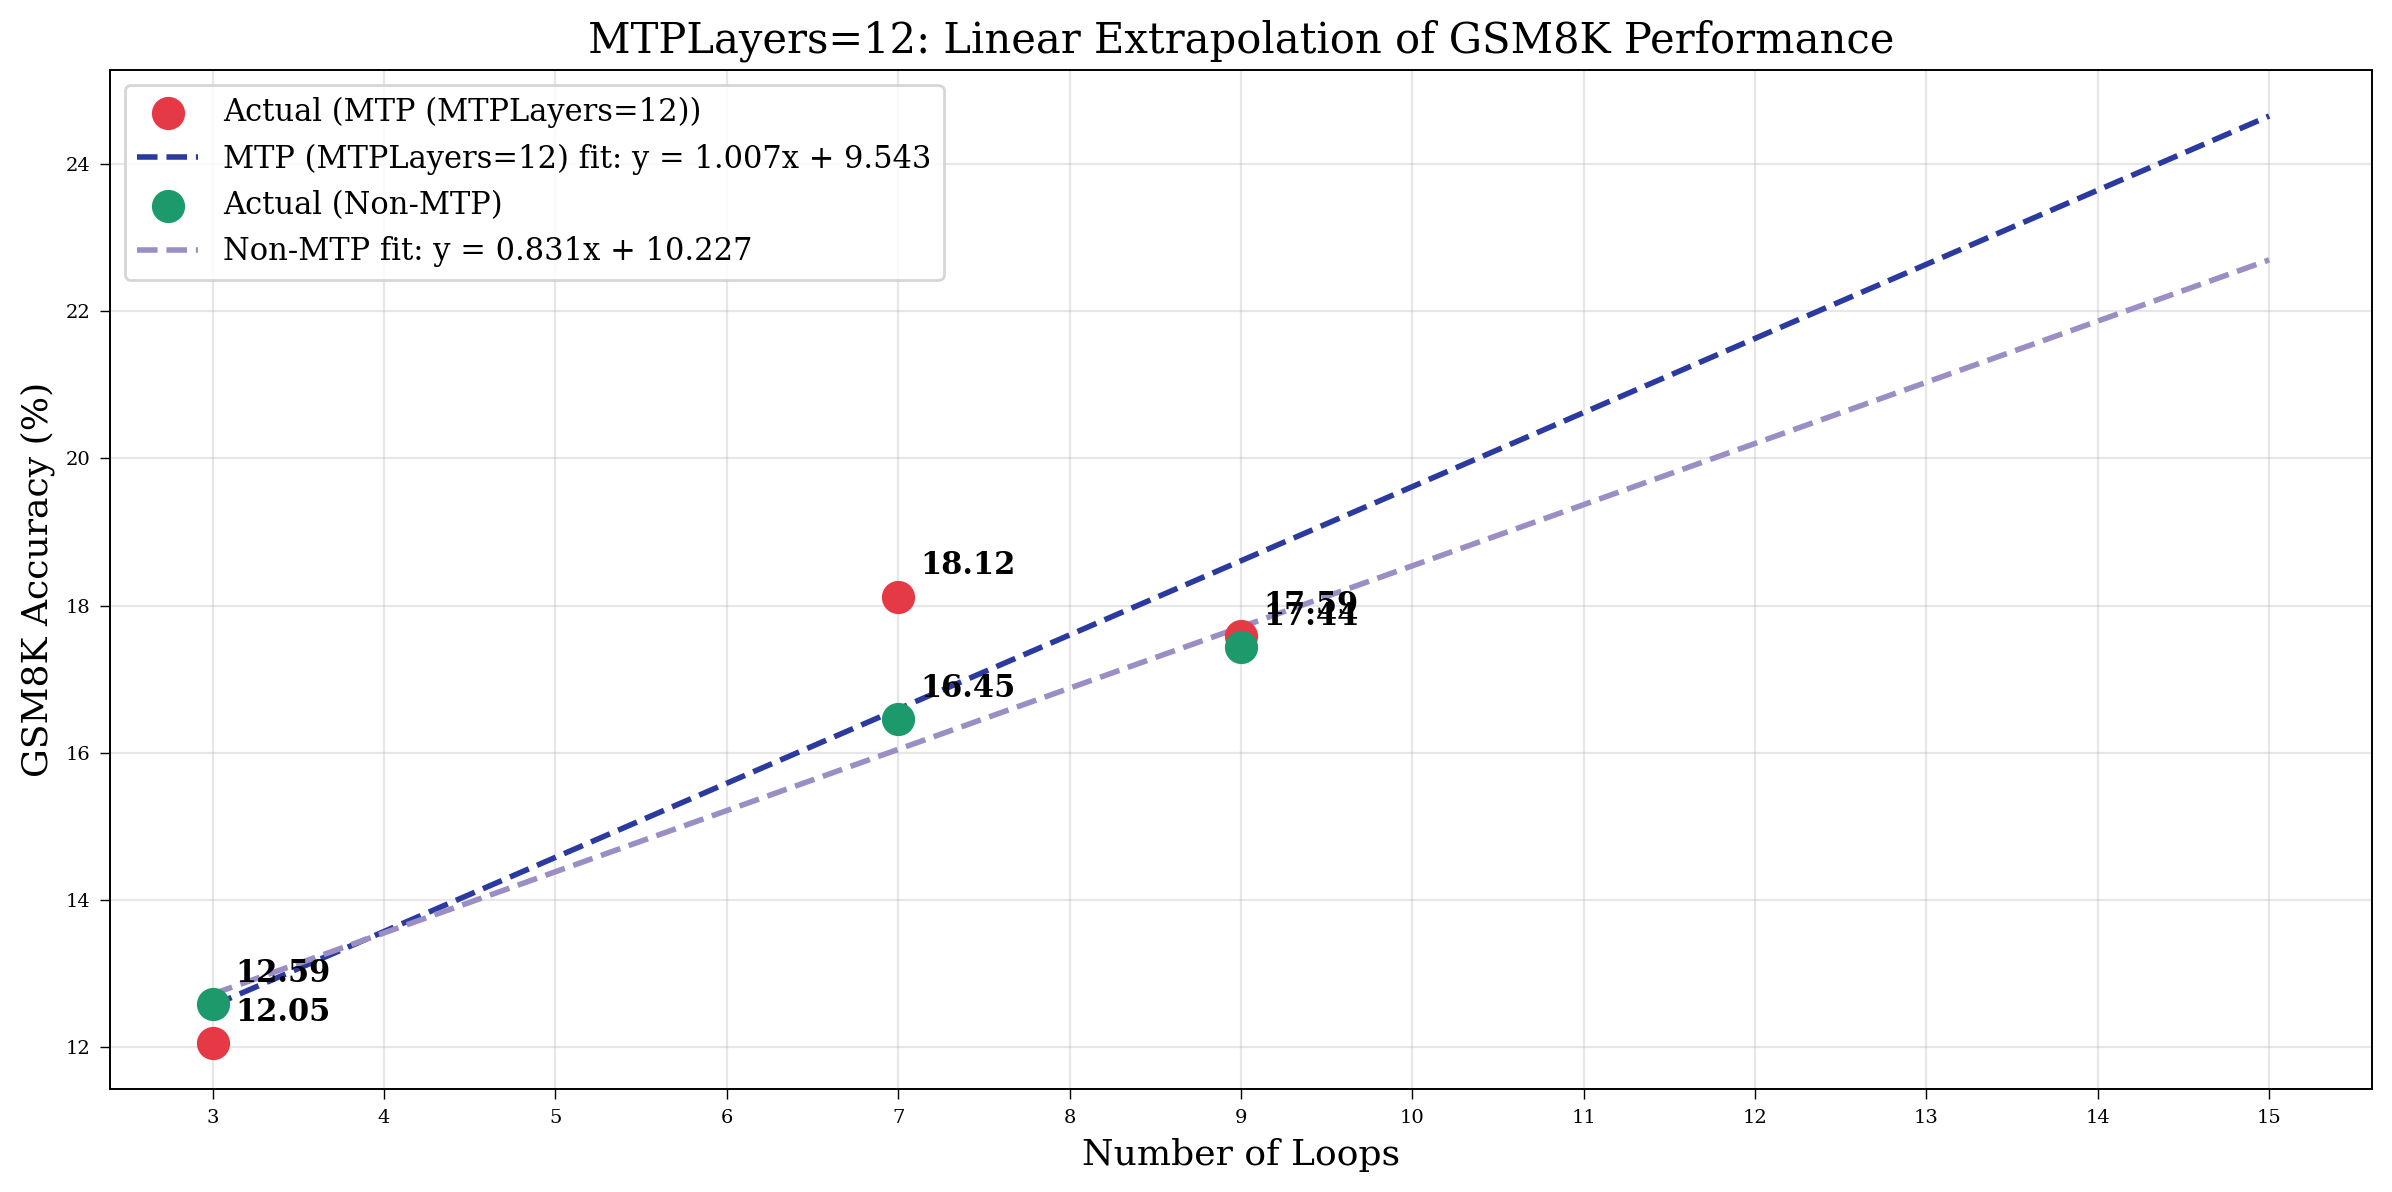

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# MTPLayers=12 data points: Loops -> accuracy (%)
loops_data = np.array([3, 5, 7, 9, 11])
# mtp_acc_data =     np.array([12.055, 14.329, 18.120, 17.589, None])
mtp_acc_data =     np.array([12.055, None,   18.120, 17.589, None])
non_mtp_acc_data = np.array([12.585, None,   16.452, 17.437, None])

series = [
    ("MTP (MTPLayers=12)", mtp_acc_data,     "#e63946", "#2b3a9e"),
    ("Non-MTP",            non_mtp_acc_data, "#1d9a6c", "#9b8ec4"),
]

# Extrapolation range
loops_extrap = np.arange(3, 16)

fig, ax = plt.subplots(figsize=(12, 6))

for name, raw, pt_color, fit_color in series:
    ys = np.array([np.nan if v is None else v for v in raw], dtype=float)
    mask = ~np.isnan(ys)
    xs_valid, ys_valid = loops_data[mask], ys[mask]

    # Fit linear regression on the valid points of this series
    coeffs = np.polyfit(xs_valid, ys_valid, 1)  # slope, intercept
    poly = np.poly1d(coeffs)

    # Actual data points
    ax.scatter(xs_valid, ys_valid, color=pt_color, s=120, zorder=5, label=f'Actual ({name})')
    for l, a in zip(xs_valid, ys_valid):
        ax.annotate(f'{a:.2f}', (l, a), textcoords="offset points", xytext=(8, 8),
                    fontsize=11, fontweight='bold')

    # Fitted / extrapolated line
    ax.plot(loops_extrap, poly(loops_extrap), '--', color=fit_color, linewidth=2,
            label=f'{name} fit: y = {coeffs[0]:.3f}x + {coeffs[1]:.3f}')

    print(f"{name}: accuracy = {coeffs[0]:.3f} * loops + {coeffs[1]:.3f}")
    for l in [9, 11, 13, 15, 20]:
        print(f"  Loops={l}: predicted = {poly(l):.3f}")
    print()

ax.set_xlabel("Number of Loops", fontsize=13)
ax.set_ylabel("GSM8K Accuracy (%)", fontsize=13)
ax.set_title("MTPLayers=12: Linear Extrapolation of GSM8K Performance", fontsize=15)
ax.set_xticks(loops_extrap)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Math expert (orig)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── ACL/EMNLP single-column style ───────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size":        8,
    "axes.titlesize":   8,
    "axes.labelsize":   8,
    "legend.fontsize":  7,
    "xtick.labelsize":  7,
    "ytick.labelsize":  7,
    "axes.linewidth":   0.7,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "lines.linewidth":  1.2,
    "figure.dpi":       200,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
})

# MTPLayers=12 data points: Loops -> accuracy (%)
loops_data = np.array([3, 5, 7])
mtp_acc_data = np.array([12.813, None, 18.12, 18.726, 15.921, 16.603, 19.03])
non_mtp_acc_data = np.array([12.737, 16.073, 19.939, ])

# Fit linear regression on the 3 MTPLayers=12 points
coeffs = np.polyfit(loops_data, mtp_acc_data, 1)  # slope, intercept
poly = np.poly1d(coeffs)

non_mtp_coeffs = np.polyfit(loops_data, non_mtp_acc_data, 1)
non_mtp_poly = np.poly1d(non_mtp_coeffs)

# Extrapolate to higher loop counts
loops_extrap = np.arange(3, 16)
mtp_acc_extrap = poly(loops_extrap)
non_mtp_acc_extrap = non_mtp_poly(loops_extrap)

# Single text-column figure (~3.3in wide)
fig, ax = plt.subplots(figsize=(3.3, 2.2))

# Actual data points
# loops_data = np.append(loops_data, 9)
# mtp_acc_data = np.append(mtp_acc_data, 18.499)
# non_mtp_acc_data = np.append(non_mtp_acc_data, 17.437) # placeholder for now



ax.scatter(loops_data, mtp_acc_data, color="#e63946", s=18, zorder=5, label="LoopMTP")
ax.scatter(loops_data, non_mtp_acc_data, color="#1d9a6c", s=18, zorder=5, label="Non-MTP")

for l, a in zip(loops_data, mtp_acc_data):
    ax.annotate(f"{a:.2f}", (l, a-0.55), textcoords="offset points", xytext=(3, 3), fontsize=6)

for l, a in zip(loops_data, non_mtp_acc_data):
    if not np.isnan(a):
        ax.annotate(f"{a:.2f}", (l, a-0.55), textcoords="offset points", xytext=(3, 3), fontsize=6)

# Fitted/extrapolated line
ax.plot(loops_extrap, mtp_acc_extrap, "--", color="#2b3a9e", linewidth=1.2,
        label=f"Linear fit: $y = {coeffs[0]:.2f}x + {coeffs[1]:.2f}$")

ax.plot(loops_extrap, non_mtp_acc_extrap, "--", color="#9b8ec4", linewidth=1.2,
        label=f"Non-MTP fit: $y = {non_mtp_coeffs[0]:.2f}x + {non_mtp_coeffs[1]:.2f}$")

# Mark a few extrapolated points
for l in [9, 11, 13, 15]:
    val = poly(l)
    ax.scatter(l, val, color="#9b8ec4", s=12, zorder=4)
    ax.annotate(f"{val:.1f}", (l-0.75, val+1.2), textcoords="offset points", xytext=(3, -7),
                fontsize=6, color="#555")
    
    non_mtp_val = non_mtp_poly(l)
    ax.scatter(l, non_mtp_val, color="#9b8ec4", s=12, zorder=4)
    ax.annotate(f"{non_mtp_val:.1f}", (l-0.75, non_mtp_val+1.2), textcoords="offset points", xytext=(3, -7),
                fontsize=6, color="#555")

ax.set_xlabel("# Loops", labelpad=1)
ax.set_ylabel("GSM8K Accuracy (\\%)", labelpad=1)
ax.set_xticks(loops_extrap)
# ax.set_ylim(12, 27)
ax.tick_params(length=2, pad=1.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle=":", linewidth=0.4, alpha=0.6, color="#aaaaaa")
ax.set_axisbelow(True)
ax.legend(frameon=True, framealpha=0.8, edgecolor="#cccccc", handlelength=1.6)

fig.tight_layout(pad=0.3)
Path("./plots").mkdir(exist_ok=True)
fig.savefig("./plots/math_expert_extrapolation.pdf", bbox_inches="tight")
plt.show()

print(f"Linear fit: accuracy = {coeffs[0]:.3f} * loops + {coeffs[1]:.3f}")
for l in [9, 11, 13, 15, 20]:
    print(f"  Loops={l}: predicted accuracy = {poly(l):.2f}%")


TypeError: unsupported operand type(s) for +: 'NoneType' and 'float'

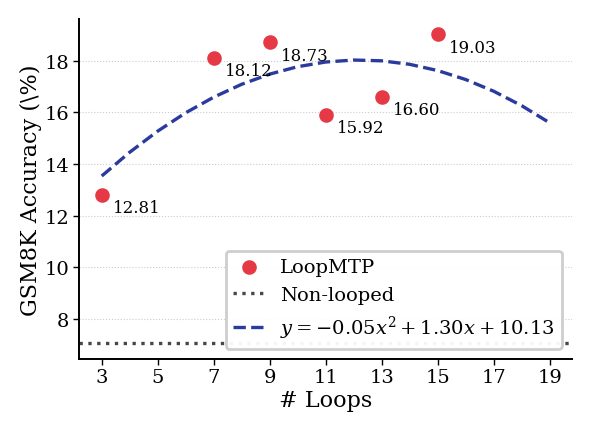

Quadratic fit: accuracy = -0.053 * loops^2 + 1.295 * loops + 10.125
  Loops=9: predicted accuracy = 17.49%
  Loops=11: predicted accuracy = 17.96%
  Loops=13: predicted accuracy = 18.01%
  Loops=15: predicted accuracy = 17.63%
  Loops=20: predicted accuracy = 14.83%


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── ACL/EMNLP single-column style ───────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size":        8,
    "axes.titlesize":   8,
    "axes.labelsize":   8,
    "legend.fontsize":  7,
    "xtick.labelsize":  7,
    "ytick.labelsize":  7,
    "axes.linewidth":   0.7,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "lines.linewidth":  1.2,
    "figure.dpi":       200,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
})

# MTPLayers=12 data points: Loops -> accuracy (%)
loops_data = np.array([3, 7, 9, 11, 13, 15])
mtp_acc_data = np.array([12.813, 18.12, 18.726, 15.921, 16.603, 19.03])

# Drop missing (None) points before fitting
mtp_acc_vals = np.array([np.nan if v is None else v for v in mtp_acc_data], dtype=float)
mask = ~np.isnan(mtp_acc_vals)
loops_valid, acc_valid = loops_data[mask], mtp_acc_vals[mask]

# Fit a degree-2 (quadratic) polynomial on the valid points
coeffs = np.polyfit(loops_valid, acc_valid, 2)  # a, b, c
poly = np.poly1d(coeffs)


# Extrapolate to higher loop counts
loops_extrap = np.arange(3, 20)
mtp_acc_extrap = poly(loops_extrap)

# Single text-column figure (~3.3in wide)
fig, ax = plt.subplots(figsize=(3., 2.2))

# # Actual data points
# loops_data = np.append(loops_data, 9)
# mtp_acc_data = np.append(mtp_acc_data, 18.499)
# non_mtp_acc_data = np.append(non_mtp_acc_data, 17.437) # placeholder for now



ax.scatter(loops_valid, acc_valid, color="#e63946", s=18, zorder=5, label="LoopMTP")

for l, a in zip(loops_valid, acc_valid):
    ax.annotate(f"{a:.2f}", (l+0.1, a-1), textcoords="offset points", xytext=(3, 3), fontsize=6)

# plot a horizontal reference line for the non-looped baseline
non_looped_baseline = 7.05
ax.axhline(non_looped_baseline, color="#48464D", linestyle=":", linewidth=1.2, label=f"Non-looped")
# ax.scatter(1, non_looped_baseline, color="#48464D", s=12, label=f"Non-looped")



# Mark a few extrapolated points
# for l in [9, 11, 13, 15, 17]:
#     val = poly(l)
#     if l == 9:
#         ax.scatter(l, val, color="#9b8ec4", s=12, zorder=4, label=f"Predicted")
#     else:
#         ax.scatter(l, val, color="#9b8ec4", s=12, zorder=4) 
#     ax.annotate(f"{val:.1f}", (l-0.75, val+1.5), textcoords="offset points", xytext=(3, -7),
#                 fontsize=6, color="#555")
    
# Fitted/extrapolated curve
ax.plot(loops_extrap, mtp_acc_extrap, "--", color="#2b3a9e", linewidth=1.2,
        label=f"$y = {coeffs[0]:.2f}x^2 + {coeffs[1]:.2f}x + {coeffs[2]:.2f}$")

ax.set_xlabel("# Loops", labelpad=1)
ax.set_ylabel("GSM8K Accuracy (\\%)", labelpad=1)
ax.set_xticks(loops_extrap[::2])
# ax.set_ylim(12, 27)
ax.tick_params(length=2, pad=1.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle=":", linewidth=0.4, alpha=0.6, color="#aaaaaa")
ax.set_axisbelow(True)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", handlelength=1.6, loc="lower right")

fig.tight_layout()
Path("./plots").mkdir(exist_ok=True)
fig.savefig("./plots/math_expert_extrapolation.pdf", bbox_inches="tight")
plt.show()

print(f"Quadratic fit: accuracy = {coeffs[0]:.3f} * loops^2 + {coeffs[1]:.3f} * loops + {coeffs[2]:.3f}")
for l in [9, 11, 13, 15, 20]:
    print(f"  Loops={l}: predicted accuracy = {poly(l):.2f}%")


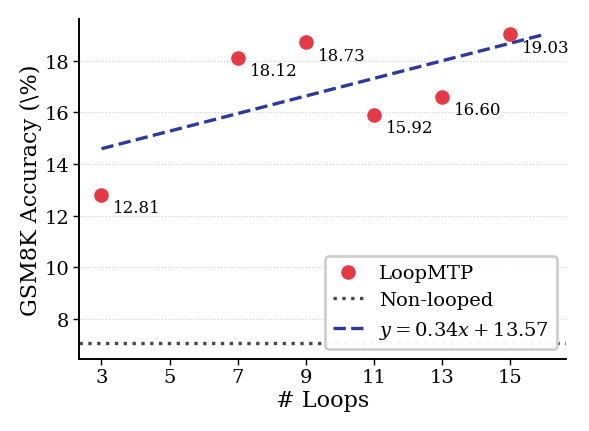

Linear fit: accuracy = 0.341 * loops + 13.571
  Loops=9: predicted accuracy = 16.64%
  Loops=11: predicted accuracy = 17.32%
  Loops=13: predicted accuracy = 18.01%
  Loops=15: predicted accuracy = 18.69%
  Loops=20: predicted accuracy = 20.39%


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── ACL/EMNLP single-column style ───────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size":        8,
    "axes.titlesize":   8,
    "axes.labelsize":   8,
    "legend.fontsize":  7,
    "xtick.labelsize":  7,
    "ytick.labelsize":  7,
    "axes.linewidth":   0.7,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "lines.linewidth":  1.2,
    "figure.dpi":       200,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
})

# MTPLayers=12 data points: Loops -> accuracy (%)
loops_data = np.array([3, 7, 9, 11, 13, 15])
mtp_acc_data = np.array([12.813, 18.12, 18.726, 15.921, 16.603, 19.03])

# Fit linear regression on the 3 MTPLayers=12 points
coeffs = np.polyfit(loops_data, mtp_acc_data, 1)  # slope, intercept
poly = np.poly1d(coeffs)


# Extrapolate to higher loop counts
loops_extrap = np.arange(3, 17)
mtp_acc_extrap = poly(loops_extrap)

# Single text-column figure (~3.3in wide)
fig, ax = plt.subplots(figsize=(3., 2.2))

# # Actual data points
# loops_data = np.append(loops_data, 9)
# mtp_acc_data = np.append(mtp_acc_data, 18.499)
# non_mtp_acc_data = np.append(non_mtp_acc_data, 17.437) # placeholder for now



ax.scatter(loops_data, mtp_acc_data, color="#e63946", s=18, zorder=5, label="LoopMTP")

for l, a in zip(loops_data, mtp_acc_data):
    ax.annotate(f"{a:.2f}", (l+0.1, a-1), textcoords="offset points", xytext=(3, 3), fontsize=6)

# plot a horizontal reference line for the non-looped baseline
non_looped_baseline = 7.05
ax.axhline(non_looped_baseline, color="#48464D", linestyle=":", linewidth=1.2, label=f"Non-looped")
# ax.scatter(1, non_looped_baseline, color="#48464D", s=12, label=f"Non-looped")



# Mark a few extrapolated points
# for l in [9, 11, 13, 15, 17]:
#     val = poly(l)
#     if l == 9:
#         ax.scatter(l, val, color="#9b8ec4", s=12, zorder=4, label=f"Predicted")
#     else:
#         ax.scatter(l, val, color="#9b8ec4", s=12, zorder=4) 
#     ax.annotate(f"{val:.1f}", (l-0.75, val+1.5), textcoords="offset points", xytext=(3, -7),
#                 fontsize=6, color="#555")
    
# Fitted/extrapolated line
ax.plot(loops_extrap, mtp_acc_extrap, "--", color="#2b3a9e", linewidth=1.2,
        label=f"$y = {coeffs[0]:.2f}x + {coeffs[1]:.2f}$")

ax.set_xlabel("# Loops", labelpad=1)
ax.set_ylabel("GSM8K Accuracy (\\%)", labelpad=1)
ax.set_xticks(loops_extrap[::2])
# ax.set_ylim(12, 27)
ax.tick_params(length=2, pad=1.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle=":", linewidth=0.4, alpha=0.6, color="#aaaaaa")
ax.set_axisbelow(True)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", handlelength=1.6, loc="lower right")

fig.tight_layout()
Path("./plots").mkdir(exist_ok=True)
fig.savefig("./plots/math_expert_extrapolation.pdf", bbox_inches="tight")
plt.show()

print(f"Linear fit: accuracy = {coeffs[0]:.3f} * loops + {coeffs[1]:.3f}")
for l in [9, 11, 13, 15, 20]:
    print(f"  Loops={l}: predicted accuracy = {poly(l):.2f}%")


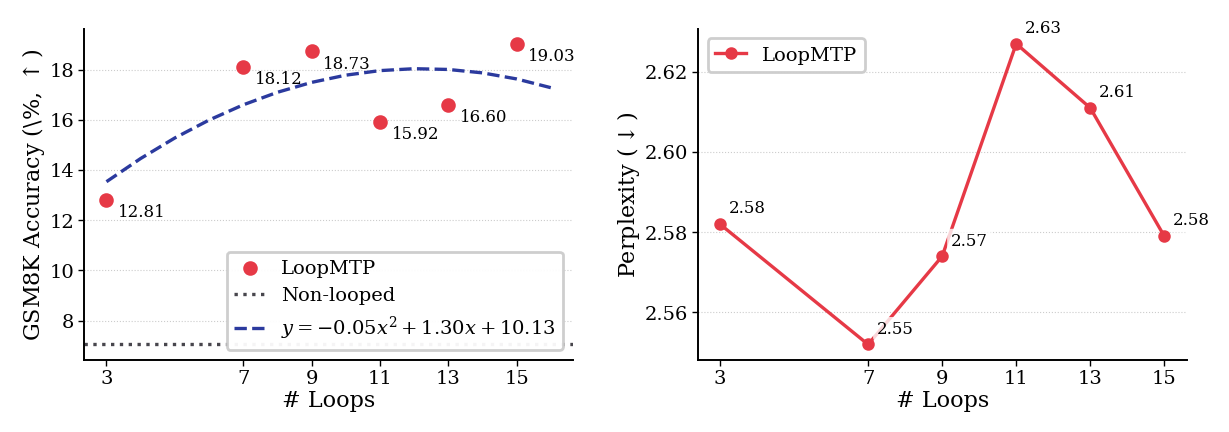

(a) Linear fit: accuracy = -0.053 * loops + 1.295
      Loops=9: predicted accuracy = 17.49%
      Loops=11: predicted accuracy = 17.96%
      Loops=13: predicted accuracy = 18.01%
      Loops=15: predicted accuracy = 17.63%
      Loops=20: predicted accuracy = 14.83%


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── ACL/EMNLP single-column style ───────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size":        8,
    "axes.titlesize":   8,
    "axes.labelsize":   8,
    "legend.fontsize":  7,
    "xtick.labelsize":  7,
    "ytick.labelsize":  7,
    "axes.linewidth":   0.7,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "lines.linewidth":  1.2,
    "figure.dpi":       200,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
})

# ─────────────────────────────────────────────────────────────────────────────
# Two-panel figure: (a) accuracy extrapolation   (b) perplexity @ 5B tokens
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.2, 2.2))

# ── Subplot (a): GSM8K accuracy vs. # loops ──────────────────────────────────
loops_data   = np.array([3, 7, 9, 11, 13, 15])
mtp_acc_data = np.array([12.813, 18.12, 18.726, 15.921, 16.603, 19.03])

coeffs = np.polyfit(loops_data, mtp_acc_data, 2)  # slope, intercept
poly   = np.poly1d(coeffs)

loops_extrap   = np.arange(3, 17)
mtp_acc_extrap = poly(loops_extrap)

ax1.scatter(loops_data, mtp_acc_data, color="#e63946", s=18, zorder=5, label="LoopMTP")
for l, a in zip(loops_data, mtp_acc_data):
    ax1.annotate(f"{a:.2f}", (l + 0.1, a - 1), textcoords="offset points", xytext=(3, 3), fontsize=6)

non_looped_baseline = 7.05
ax1.axhline(non_looped_baseline, color="#48464D", linestyle=":", linewidth=1.2, label="Non-looped")

ax1.plot(loops_extrap, mtp_acc_extrap, "--", color="#2b3a9e", linewidth=1.2,
         label=f"$y = {coeffs[0]:.2f}x^2 + {coeffs[1]:.2f}x + {coeffs[2]:.2f}$")

ax1.set_xlabel("# Loops", labelpad=1)
ax1.set_ylabel("GSM8K Accuracy (\\%, $\\uparrow$)", labelpad=1)
# ax1.set_xticks(loops_extrap[::2])
ax1.set_xticks(loops_data)
ax1.tick_params(length=2, pad=1.5)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.yaxis.grid(True, linestyle=":", linewidth=0.4, alpha=0.6, color="#aaaaaa")
ax1.set_axisbelow(True)
# ax1.set_title("(a) Accuracy extrapolation", pad=3)
ax1.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", handlelength=1.6, loc="lower right")

# ── Subplot (b): perplexity @ 5B tokens vs. # loops ──────────────────────────
# !!! DUMMY NUMBERS — replace with the real perplexity @ 5B tokens !!!
loops_ppl    = np.array([3, 7, 9, 11, 13, 15])
ppl_data     = np.array([2.582, 2.552, 2.574, 2.627, 2.611, 2.579])
# ppl_baseline = 16.5  # non-looped baseline (dummy)

ax2.plot(loops_ppl, ppl_data, "-o", color="#e63946", markersize=3.5, linewidth=1.2,
         zorder=5, label="LoopMTP")
for l, p in zip(loops_ppl, ppl_data):
    ax2.annotate(f"{p:.2f}", (l, p), textcoords="offset points", xytext=(3, 4), fontsize=6,
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
                 zorder=6)

# ax2.axhline(ppl_baseline, color="#48464D", linestyle=":", linewidth=1.2, label="Non-looped")

ax2.set_xlabel("# Loops", labelpad=1)
ax2.set_ylabel("Perplexity ($\\downarrow$)", labelpad=1)
ax2.set_xticks(loops_ppl)
ax2.tick_params(length=2, pad=1.5)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.yaxis.grid(True, linestyle=":", linewidth=0.4, alpha=0.6, color="#aaaaaa")
ax2.set_axisbelow(True)
# ax2.set_title("(b) Perplexity @ 5B tokens", pad=3)
ax2.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", handlelength=1.6, loc="upper left")

fig.tight_layout(w_pad=1.5)
Path("./plots").mkdir(exist_ok=True)
fig.savefig("./plots/math_expert_extrapolation_with_ppl.pdf", bbox_inches="tight")
plt.show()

print(f"(a) Linear fit: accuracy = {coeffs[0]:.3f} * loops + {coeffs[1]:.3f}")
for l in [9, 11, 13, 15, 20]:
    print(f"      Loops={l}: predicted accuracy = {poly(l):.2f}%")


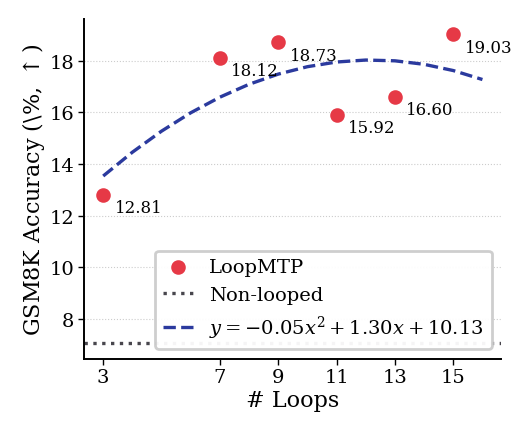

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── ACL/EMNLP single-column style ───────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size":        8,
    "axes.titlesize":   8,
    "axes.labelsize":   8,
    "legend.fontsize":  7,
    "xtick.labelsize":  7,
    "ytick.labelsize":  7,
    "axes.linewidth":   0.7,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "lines.linewidth":  1.2,
    "figure.dpi":       200,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
})

# ─────────────────────────────────────────────────────────────────────────────
# Two-panel figure: (a) accuracy extrapolation   (b) perplexity @ 5B tokens
# ─────────────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(1, 1, figsize=(2.7, 2.2))

# ── Subplot (a): GSM8K accuracy vs. # loops ──────────────────────────────────
loops_data   = np.array([3, 7, 9, 11, 13, 15])
mtp_acc_data = np.array([12.813, 18.12, 18.726, 15.921, 16.603, 19.03])

coeffs = np.polyfit(loops_data, mtp_acc_data, 2)  # slope, intercept
poly   = np.poly1d(coeffs)

loops_extrap   = np.arange(3, 17)
mtp_acc_extrap = poly(loops_extrap)

ax1.scatter(loops_data, mtp_acc_data, color="#e63946", s=18, zorder=5, label="LoopMTP")
for l, a in zip(loops_data, mtp_acc_data):
    ax1.annotate(f"{a:.2f}", (l + 0.1, a - 1), textcoords="offset points", xytext=(3, 3), fontsize=6)

non_looped_baseline = 7.05
ax1.axhline(non_looped_baseline, color="#48464D", linestyle=":", linewidth=1.2, label="Non-looped")

ax1.plot(loops_extrap, mtp_acc_extrap, "--", color="#2b3a9e", linewidth=1.2,
         label=f"$y = {coeffs[0]:.2f}x^2 + {coeffs[1]:.2f}x + {coeffs[2]:.2f}$")

ax1.set_xlabel("# Loops", labelpad=1)
ax1.set_ylabel("GSM8K Accuracy (\\%, $\\uparrow$)", labelpad=1)
# ax1.set_xticks(loops_extrap[::2])
ax1.set_xticks(loops_data)
ax1.tick_params(length=2, pad=1.5)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.yaxis.grid(True, linestyle=":", linewidth=0.4, alpha=0.6, color="#aaaaaa")
ax1.set_axisbelow(True)
# ax1.set_title("(a) Accuracy extrapolation", pad=3)
ax1.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", handlelength=1.6, loc="lower right")

fig.tight_layout()
Path("./plots").mkdir(exist_ok=True)
fig.savefig("./plots/math_expert_extrapolation_wo_ppl.pdf", bbox_inches="tight")
